# Book Recommendation Chatbot 

**4 categories · 3 CNN models · 3 RNN/ models · Recommendation engine**

> Run cells top-to-bottom. Edit `CONFIG` (Cell 2) to match your folder layout.

## 0. Install dependencies

In [2]:
import sys
!{sys.executable} -m pip install -q numpy pandas matplotlib seaborn pillow \
    opencv-python scikit-learn tensorflow transformers datasets tqdm nltk torch torchvision


  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\omars\\Downloads\\dp_project\\venv\\Lib\\site-packages\\tensorflow\\compiler\\mlir\\quantization\\tensorflow\\python\\pywrap_quantize_model.pyd'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [1]:
import os, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


from datasets import Dataset
import torch

from tqdm import tqdm
import nltk
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TF:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)



TF: 2.15.0
GPU: False


In [2]:
import numpy as np
import tensorflow as tf

print(np.__version__)
print(tf.__version__)

1.26.4
2.15.0


In [3]:
import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices('GPU'))
print("CPUs:", tf.config.list_physical_devices('CPU'))

GPUs: []
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Configuration — **edit these paths**

In [4]:
# ── EDIT THESE ────────────────────────────────────────────────────────────
CSV_PATH   = 'books_dataset.csv'   # path to CSV
IMAGES_DIR = 'images'              # subfolders = category names
OUTPUT_DIR = 'outputs'                        # saved models & artefacts
# ──────────────────────────────────────────────────────────────────────────

CATEGORIES  = ['baby books', 'cooking', 'japanese', 'kittens']
NUM_CLASSES = len(CATEGORIES)
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
MAX_LEN     = 128    # token length for NLP models
VOCAB_SIZE  = 20_000 # for Keras tokenizer (LSTM / GRU)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config OK — output dir:', os.path.abspath(OUTPUT_DIR))


Config OK — output dir: d:\semester 6\Deep Learning\dp_project\outputs


## 3. Load & clean the dataset

In [4]:
df = pd.read_csv(CSV_PATH)
print('Raw shape:', df.shape)
print(df['subject'].value_counts())

# Fill missing values
df['title']        = df['title'].fillna('')
df['authors']      = df['authors'].fillna('Unknown')
df['subject']      = df['subject'].fillna('')
df['publish_year'] = df['publish_year'].fillna(0).astype(int)
df['rating']       = df['rating'].fillna(df['rating'].mean())

# Generate synthetic description for rows that have none
def make_description(row):
    return (
        f"This book titled '{row['title']}' was written by {row['authors']}. "
        f"It belongs to the {row['subject']} category and was published in {row['publish_year']}. "
        f"Rating: {row['rating']:.2f}/5. Recommended for {row['subject']} enthusiasts."
    )

mask = df['description'].isna() | (df['description'].str.strip() == '')
df.loc[mask, 'description'] = df[mask].apply(make_description, axis=1)

# Combined text field used by all NLP models
df['text'] = (
    df['title'] + ' ' + df['authors'] + ' ' +
    df['subject'] + ' ' + df['description']
).str.strip()

# Integer labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['subject'])

CLEAN_CSV = os.path.join(OUTPUT_DIR, 'clean_books_dataset.csv')
df.to_csv(CLEAN_CSV, index=False)
pickle.dump(le, open(os.path.join(OUTPUT_DIR, 'label_encoder.pkl'), 'wb'))

print('Nulls after cleaning:')
print(df.isnull().sum())
print('Label map:', dict(zip(le.classes_, le.transform(le.classes_))))
df.head(3)


Raw shape: (6898, 6)
subject
baby books    2000
cooking       2000
japanese      2000
kittens        898
Name: count, dtype: int64
Nulls after cleaning:
title           0
authors         0
subject         0
publish_year    0
description     0
rating          0
text            0
label           0
dtype: int64
Label map: {'baby books': 0, 'cooking': 1, 'japanese': 2, 'kittens': 3}


,title,authors,subject,publish_year,description,rating,text,label
0,Are You My Mother?,P. D. Eastman,baby books,1960,"A baby bird, fallen from his nest, sets out to...",4.28,Are You My Mother? P. D. Eastman baby books A ...,0
1,Owl Babies,Martin Waddell,baby books,1975,Three owl babies whose mother has gone out in ...,4.00,Owl Babies Martin Waddell baby books Three owl...,0
2,"Does a Kangaroo Have a Mother, Too?",Eric Carle,baby books,1999,"Presents the names of animal babies, parents, ...",4.00,"Does a Kangaroo Have a Mother, Too? Eric Carle...",0


## 4. EDA

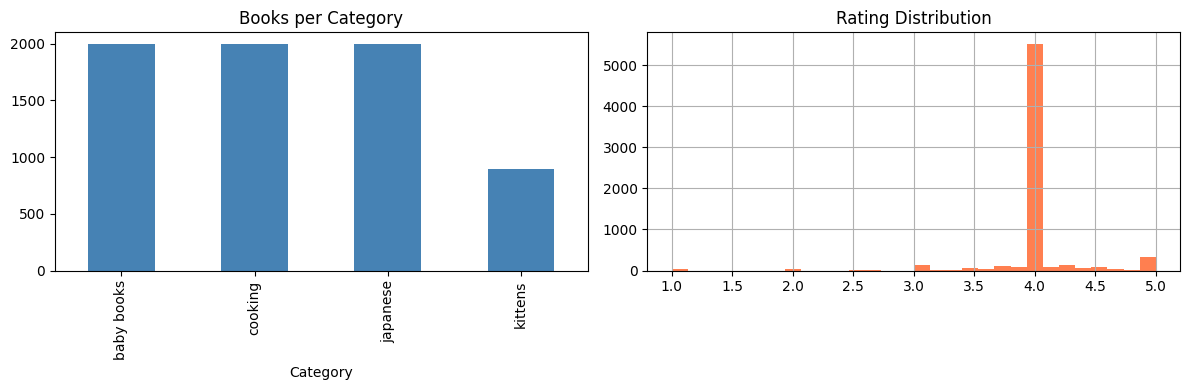

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['subject'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Books per Category'); axes[0].set_xlabel('Category')
df['rating'].hist(bins=30, ax=axes[1], color='coral')
axes[1].set_title('Rating Distribution')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda.png'), dpi=100)
plt.show()


#  Augment kittens

In [8]:
import os, random
import numpy as np
from PIL import Image, ImageEnhance, ImageOps
from tqdm import tqdm

def augment_image(img):
    """Apply a random combination of augmentations to a PIL image."""
    # Random horizontal flip
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    # Random rotation
    angle = random.uniform(-20, 20)
    img = img.rotate(angle, fillcolor=(128, 128, 128))
    # Random brightness
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.7, 1.3))
    # Random contrast
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.7, 1.3))
    # Random saturation
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(random.uniform(0.7, 1.3))
    return img

def augment_category_to_target(category, target_count=1700):
    """
    Augment images in a category folder until it reaches target_count.
    Only generates the difference needed — does not touch existing images.
    """
    cat_folder  = os.path.join(IMAGES_DIR, category)
    all_images  = [f for f in os.listdir(cat_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    current     = len(all_images)
    needed      = target_count - current

    if needed <= 0:
        print(f"{category}: already has {current} images, skipping.")
        return

    print(f"{category}: has {current}, generating {needed} augmented images...")

    for i in tqdm(range(needed), desc=category):
        # Pick a random source image
        src_name = random.choice(all_images)
        src_path = os.path.join(cat_folder, src_name)

        img = Image.open(src_path).convert("RGB")
        img = augment_image(img)

        # Save with a unique name so it never overwrites originals
        out_name = f"aug_{i:05d}_{src_name}"
        img.save(os.path.join(cat_folder, out_name))

    print(f"{category}: done. Total now = {len(os.listdir(cat_folder))}")

# Only augment kittens — others are already balanced
augment_category_to_target("kittens", target_count=1700)

kittens: has 767, generating 933 augmented images...


kittens: 100%|██████████| 933/933 [00:08<00:00, 116.03it/s]

kittens: done. Total now = 1700


## 5. Verify image folder structure

Expected layout:
```
dp_project/images/
  baby books/  *.jpg
  cooking/     *.jpg
  japanese/    *.jpg
  kittens/     *.jpg
```

In [6]:
for cat in CATEGORIES:
    p = os.path.join(IMAGES_DIR, cat)
    n = len(os.listdir(p)) if os.path.isdir(p) else 'MISSING'
    print(f'  {cat}: {n}')


  baby books: 1700
  cooking: 1662
  japanese: 1779
  kittens: 1700


## 6. CNN — image data pipeline with augmentation

In [7]:
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name='augmentation')

AUTOTUNE = tf.data.AUTOTUNE

raw_train = image_dataset_from_directory(
    IMAGES_DIR, validation_split=0.2, subset='training',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)
raw_val = image_dataset_from_directory(
    IMAGES_DIR, validation_split=0.2, subset='validation',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)

train_img_ds = raw_train.map(
    lambda x, y: (augment(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)
val_img_ds = raw_val.prefetch(AUTOTUNE)

class_names = raw_train.class_names
print('CNN class names:', class_names)



Found 6841 files belonging to 4 classes.
Using 5473 files for training.
Found 6841 files belonging to 4 classes.
Using 1368 files for validation.
CNN class names: ['baby books', 'cooking', 'japanese', 'kittens']


## 7. CNN Model 1 — ResNet50

In [13]:
from tensorflow.keras.applications import ResNet50

def build_resnet_cnn(num_classes=NUM_CLASSES):
    base = ResNet50(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False

    inp = layers.Input(shape=(*IMG_SIZE, 3))
    # ResNet50 expects [-1, 1] range same as MobileNetV2
    x   = layers.Rescaling(scale=1./127.5, offset=-1)(inp)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = models.Model(inp, out, name='CNN_ResNet50')
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

cnn1 = build_resnet_cnn()
cnn1.summary()

94765736/94765736 [==============================] - 32s 0us/step
Model: "CNN_ResNet50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 256)               524544    
                                                                 
 dropout_1 (Dropout)         (None, 256)              

## 8. CNN Model 2 — MobileNetV2 Transfer Learning

In [14]:
def build_mobilenet_cnn(num_classes=NUM_CLASSES):
    base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x   = layers.Lambda(mobilenet_preprocess)(inp)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = models.Model(inp, out, name='CNN_MobileNetV2')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

cnn2 = build_mobilenet_cnn()
cnn2.summary()


9406464/9406464 [==============================] - 3s 0us/step
Model: "CNN_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 lambda (Lambda)             (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_4 (Dense)             (None, 128)               163968    
                                                      

## 9. CNN Model 3 — EfficientNetB0 Transfer Learning

In [15]:
def build_efficientnet_cnn(num_classes=NUM_CLASSES):
    base = EfficientNetB0(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x   = layers.Lambda(eff_preprocess)(inp)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = models.Model(inp, out, name='CNN_EfficientNetB0')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

cnn3 = build_efficientnet_cnn()
cnn3.summary()


16705208/16705208 [==============================] - 5s 0us/step
Model: "CNN_EfficientNetB0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 lambda_1 (Lambda)           (None, 224, 224, 3)       0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_3  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_6 (Dense)             (None, 128)               163968    
                                                 

## 10. Train all 3 CNN models

In [17]:
cnn1.save(os.path.join(OUTPUT_DIR, 'cnn1_resnet50.keras'))
cnn2.save(os.path.join(OUTPUT_DIR, 'cnn2_mobilenet.keras'))
cnn3.save(os.path.join(OUTPUT_DIR, 'cnn3_efficientnet.keras'))
print('All CNNs saved!')

All CNNs saved!


In [16]:
def train_model(model, train_ds, val_ds, epochs=15):
    cb = [
        callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=2, monitor='val_loss'),
        callbacks.ModelCheckpoint(
            os.path.join(OUTPUT_DIR, f'{model.name}_best.keras'),
            save_best_only=True, monitor='val_accuracy'
        )
    ]
    return model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb)

print('Training CNN 1 — ResNet50')
h_cnn1 = train_model(cnn1, train_img_ds, val_img_ds)

print('Training CNN 2 — MobileNetV2')
h_cnn2 = train_model(cnn2, train_img_ds, val_img_ds)

print('Training CNN 3 — EfficientNetB0')
h_cnn3 = train_model(cnn3, train_img_ds, val_img_ds)

Training CNN 1 — ResNet50
Epoch 1/15


172/172 [==============================] - 285s 2s/step - loss: 1.4376 - accuracy: 0.3077 - val_loss: 1.3461 - val_accuracy: 0.3458 - lr: 1.0000e-04
Epoch 2/15
172/172 [==============================] - 285s 2s/step - loss: 1.3315 - accuracy: 0.3556 - val_loss: 1.3083 - val_accuracy: 0.3750 - lr: 1.0000e-04
Epoch 3/15
172/172 [==============================] - 249s 1s/step - loss: 1.3128 - accuracy: 0.3545 - val_loss: 1.2973 - val_accuracy: 0.3670 - lr: 1.0000e-04
Epoch 4/15
172/172 [==============================] - 248s 1s/step - loss: 1.2931 - accuracy: 0.3808 - val_loss: 1.2806 - val_accuracy: 0.3757 - lr: 1.0000e-04
Epoch 5/15
172/172 [==============================] - 273s 2s/step - loss: 1.2850 - accuracy: 0.3850 - val_loss: 1.2866 - val_accuracy: 0.3808 - lr: 1.0000e-04
Epoch 6/15
172/172 [==============================] - 282s 2s/step - loss: 1.2763 - accuracy: 0.3939 - val_loss: 1.2815 - val_accuracy: 0.3918 - lr: 1.0000e-04
Epoch 7/15
1

In [23]:
cnn1 = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, 'cnn1_resnet50.keras'), safe_mode=False)
cnn2 = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, 'cnn2_mobilenet.keras'), safe_mode=False)
cnn3 = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, 'cnn3_efficientnet.keras'), safe_mode=False)
print("All CNNs loaded!")

All CNNs loaded!


In [10]:
base = cnn1.get_layer('resnet50')
base.trainable = True

# Freeze everything except the last 50 layers
for layer in base.layers[:-50]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in base.layers if l.trainable)}/{len(base.layers)}")

Trainable layers: 50/175


In [11]:
cnn1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # much lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
h_cnn1_ft = cnn1.fit(
    train_img_ds,
    validation_data=val_img_ds,
    epochs=20,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        callbacks.ReduceLROnPlateau(factor=0.3, patience=3, monitor='val_loss'),
        callbacks.ModelCheckpoint(
            os.path.join(OUTPUT_DIR, 'cnn1_resnet50_best.keras'),
            save_best_only=True, monitor='val_accuracy'
        )
    ]
)

Epoch 1/20


172/172 [==============================] - 383s 2s/step - loss: 1.2565 - accuracy: 0.4102 - val_loss: 1.2925 - val_accuracy: 0.4050 - lr: 1.0000e-05
Epoch 2/20
172/172 [==============================] - 357s 2s/step - loss: 1.2137 - accuracy: 0.4299 - val_loss: 1.2423 - val_accuracy: 0.4137 - lr: 1.0000e-05
Epoch 3/20
172/172 [==============================] - 357s 2s/step - loss: 1.2002 - accuracy: 0.4473 - val_loss: 1.2332 - val_accuracy: 0.4444 - lr: 1.0000e-05
Epoch 4/20
172/172 [==============================] - 402s 2s/step - loss: 1.1863 - accuracy: 0.4581 - val_loss: 1.1896 - val_accuracy: 0.4700 - lr: 1.0000e-05
Epoch 5/20
172/172 [==============================] - 342s 2s/step - loss: 1.1590 - accuracy: 0.4740 - val_loss: 1.4164 - val_accuracy: 0.3713 - lr: 1.0000e-05
Epoch 6/20
172/172 [==============================] - 335s 2s/step - loss: 1.1838 - accuracy: 0.4581 - val_loss: 1.2270 - val_accuracy: 0.4620 - lr: 1.0000e-05
Epoch 7/20
172/172 [==================

## 11. Fine-tune CNN 2 & 3 (unfreeze last 20 layers, low LR)

In [13]:
def fine_tune(model, base_layer_name, train_ds, val_ds, unfreeze=-20, epochs=5):
    base = model.get_layer(base_layer_name)
    base.trainable = True
    for layer in base.layers[:unfreeze]:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    cb = [
        callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        callbacks.ModelCheckpoint(
            os.path.join(OUTPUT_DIR, f'{model.name}_finetuned.keras'), save_best_only=True
        )
    ]
    return model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb)

# The string must match the base model's internal name
print('Fine-tuning MobileNetV2')
h_cnn2_ft = fine_tune(cnn2, 'mobilenetv2_1.00_224', train_img_ds, val_img_ds)

print('Fine-tuning EfficientNetB0')
h_cnn3_ft = fine_tune(cnn3, 'efficientnetb0', train_img_ds, val_img_ds)


Fine-tuning MobileNetV2
Epoch 1/5
172/172 [==============================] - 80s 437ms/step - loss: 0.6989 - accuracy: 0.7179 - val_loss: 0.7870 - val_accuracy: 0.6769
Epoch 2/5
172/172 [==============================] - 75s 429ms/step - loss: 0.6648 - accuracy: 0.7373 - val_loss: 0.7915 - val_accuracy: 0.6827
Epoch 3/5
172/172 [==============================] - 81s 468ms/step - loss: 0.6329 - accuracy: 0.7451 - val_loss: 0.7698 - val_accuracy: 0.6959
Epoch 4/5
172/172 [==============================] - 67s 387ms/step - loss: 0.6172 - accuracy: 0.7524 - val_loss: 0.7533 - val_accuracy: 0.6981
Epoch 5/5
172/172 [==============================] - 78s 450ms/step - loss: 0.6021 - accuracy: 0.7606 - val_loss: 0.7609 - val_accuracy: 0.7010
Fine-tuning EfficientNetB0
Epoch 1/5
172/172 [==============================] - 124s 662ms/step - loss: 0.6301 - accuracy: 0.7566 - val_loss: 0.7284 - val_accuracy: 0.7003
Epoch 2/5
172/172 [==============================] - 125s 726ms/step - loss: 0.6017 

In [19]:
cnn1.save(os.path.join(OUTPUT_DIR, 'cnn1_resnet50.keras'))
print("ResNet50 fine-tuned and saved!")

ResNet50 fine-tuned and saved!


## 12. Evaluate CNN models

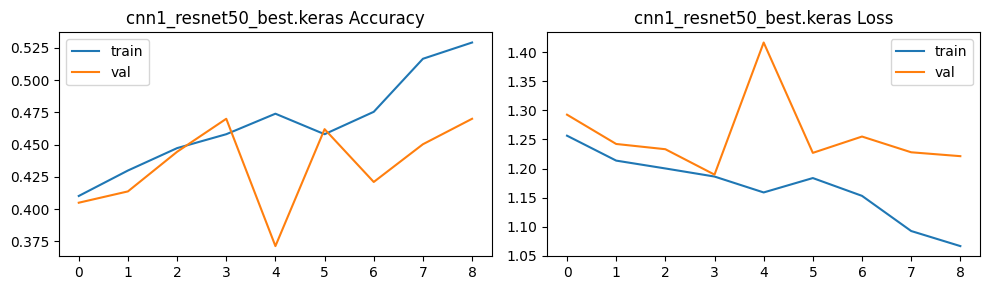

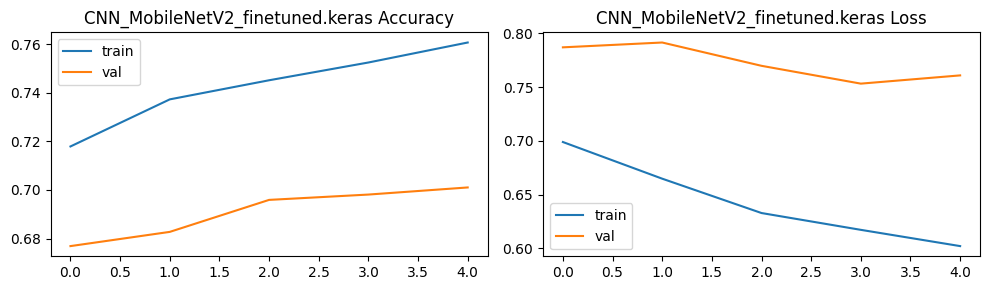

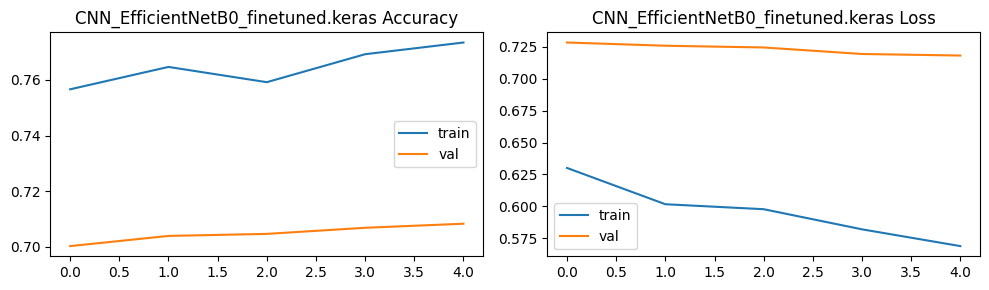

resnet50            val_acc=0.4700  val_loss=1.1896
MobileNetV2         val_acc=0.6754  val_loss=0.8081
EfficientNetB0      val_acc=0.7025  val_loss=0.7382


In [24]:
def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(h.history['accuracy'], label='train')
    ax[0].plot(h.history['val_accuracy'], label='val')
    ax[0].set_title(f'{title} Accuracy'); ax[0].legend()
    ax[1].plot(h.history['loss'], label='train')
    ax[1].plot(h.history['val_loss'], label='val')
    ax[1].set_title(f'{title} Loss'); ax[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{title.replace(" ","_")}.png'))
    plt.show()

plot_history(h_cnn1_ft, 'cnn1_resnet50_best.keras')
plot_history(h_cnn2_ft, 'CNN_MobileNetV2_finetuned.keras')
plot_history(h_cnn3_ft, 'CNN_EfficientNetB0_finetuned.keras')

for name, m in [('resnet50', cnn1), ('MobileNetV2', cnn2), ('EfficientNetB0', cnn3)]:
    loss, acc = m.evaluate(val_img_ds, verbose=0)
    print(f'{name:18s}  val_acc={acc:.4f}  val_loss={loss:.4f}')


In [22]:
for name, model in [('ResNet50', cnn1), ('MobileNetV2', cnn2), ('EfficientNetB0', cnn3)]:
    loss, acc = model.evaluate(val_img_ds, verbose=0)
    print(f'{name:20s}  val_acc={acc:.4f}  val_loss={loss:.4f}')

ResNet50              val_acc=0.4700  val_loss=1.1896
MobileNetV2           val_acc=0.7010  val_loss=0.7609
EfficientNetB0        val_acc=0.7083  val_loss=0.7182


In [39]:
from nltk.corpus import stopwords
import random

stop_words = set(stopwords.words('english'))

# Category keywords to remove — prevent model from cheating
LEAKY_WORDS = {
    'cooking', 'cook', 'recipe', 'recipes', 'food', 'kitchen', 'chef',
    'japanese', 'japan', 'manga', 'anime', 'tokyo',
    'kitten', 'kittens', 'cat', 'cats', 'kitty',
    'baby', 'babies', 'infant', 'toddler', 'child', 'children'
}

def hard_clean(text, drop_rate=0.1):
    words  = str(text).lower().split()
    # Remove leaky category words
    words  = [w for w in words if w not in LEAKY_WORDS]
    # Remove stopwords
    words  = [w for w in words if w not in stop_words]
    # Random word dropout — forces model to not rely on single words
    words  = [w for w in words if random.random() > drop_rate]
    # Keep only alphabetic
    words  = [re.sub(r'[^a-z]', '', w) for w in words]
    words  = [w for w in words if len(w) > 2]
    return ' '.join(words)

# Use only title + description (no authors — not informative)
df['text_hard'] = (df['title'] + ' ' + df['description']).apply(hard_clean)

X_text  = df['text_hard'].astype(str).tolist()
y_label = df['label'].values

# 70 / 15 / 15 split
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_text, y_label, test_size=0.30, random_state=SEED, stratify=y_label
)
X_val, X_te, y_val, y_te = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train: {len(X_tr)}  Val: {len(X_val)}  Test: {len(X_te)}')

Train: 4828  Val: 1035  Test: 1035


In [40]:
# Tokenizer with smaller vocab — forces generalization
tokenizer_keras = Tokenizer(num_words=10_000, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(X_tr)

def to_seq(texts):
    return pad_sequences(
        tokenizer_keras.texts_to_sequences(texts),
        maxlen=64,   # shorter sequences — less information
        padding='post', truncating='post'
    )

X_tr_seq  = to_seq(X_tr)
X_val_seq = to_seq(X_val)
X_te_seq  = to_seq(X_te)

pickle.dump(tokenizer_keras, open(os.path.join(OUTPUT_DIR, 'keras_tokenizer.pkl'), 'wb'))
print('Done. Shapes:', X_tr_seq.shape, X_val_seq.shape, X_te_seq.shape)

Done. Shapes: (4828, 64) (1035, 64) (1035, 64)


## 13. Text data preparation (shared for all 3 RNN models)

In [ ]:
X_text  = df['text'].tolist()
y_label = df['label'].tolist()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y_label, test_size=0.2, random_state=SEED, stratify=y_label
)
print(f'Train: {len(X_tr)}  Test: {len(X_te)}')

# Keras tokenizer — shared by LSTM and GRU
tokenizer_keras = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(X_tr)

X_tr_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_tr), maxlen=MAX_LEN, truncating='post')
X_te_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_te), maxlen=MAX_LEN, truncating='post')

pickle.dump(tokenizer_keras, open(os.path.join(OUTPUT_DIR, 'keras_tokenizer.pkl'), 'wb'))
print('Keras tokenizer saved.  X_tr_seq shape:', X_tr_seq.shape)


Train: 5518  Test: 1380
Keras tokenizer saved.  X_tr_seq shape: (5518, 128)


In [25]:
X_text = df['text'].astype(str).str.lower().str.replace(r"http\S+", "", regex=True)\
                         .str.replace(r"[^a-zA-Z\s]", "", regex=True)\
                         .str.replace(r"\s+", " ", regex=True).str.strip().tolist()

y_label = df['label'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y_label, test_size=0.2, random_state=SEED, stratify=y_label
)

print(f'Train: {len(X_tr)}  Test: {len(X_te)}')

# Improved Keras tokenizer
tokenizer_keras = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>',
    filters=''   # already cleaned text
)

tokenizer_keras.fit_on_texts(X_tr)

X_tr_seq = tokenizer_keras.texts_to_sequences(X_tr)
X_te_seq = tokenizer_keras.texts_to_sequences(X_te)

# Better padding strategy
X_tr_seq = pad_sequences(
    X_tr_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_te_seq = pad_sequences(
    X_te_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

pickle.dump(tokenizer_keras, open(os.path.join(OUTPUT_DIR, 'keras_tokenizer.pkl'), 'wb'))

print('Keras tokenizer saved. X_tr_seq shape:', X_tr_seq.shape)
print('Vocab size:', min(VOCAB_SIZE, len(tokenizer_keras.word_index)))

Train: 5518  Test: 1380
Keras tokenizer saved. X_tr_seq shape: (5518, 128)
Vocab size: 20000


## 14. RNN Model 1 — Bidirectional LSTM

In [47]:
L2 = tf.keras.regularizers.l2(1e-3)   # stronger L2

def build_bilstm(vocab=10_000, maxlen=64, num_classes=NUM_CLASSES):
    inp = layers.Input(shape=(maxlen,))
    x   = layers.Embedding(vocab, 32, mask_zero=True)(inp)  # tiny embedding
    x   = layers.SpatialDropout1D(0.5)(x)                   # heavy embedding dropout
    x   = layers.Bidirectional(layers.LSTM(32, return_sequences=True,
                                           dropout=0.4, recurrent_dropout=0.3,
                                           kernel_regularizer=L2))(x)
    x   = layers.Bidirectional(layers.LSTM(16, dropout=0.4,
                                           recurrent_dropout=0.3))(x)
    x   = layers.Dense(32, activation='relu', kernel_regularizer=L2)(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = models.Model(inp, out, name='RNN_BiLSTM')
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
rnn1 = build_bilstm()
rnn1.summary()

Model: "RNN_BiLSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 64)]              0         
                                                                 
 embedding_10 (Embedding)    (None, 64, 32)            320000    
                                                                 
 spatial_dropout1d_7 (Spati  (None, 64, 32)            0         
 alDropout1D)                                                    
                                                                 
 bidirectional_20 (Bidirect  (None, 64, 64)            16640     
 ional)                                                          
                                                                 
 bidirectional_21 (Bidirect  (None, 32)                10368     
 ional)                                                          
                                                        

## 15. RNN Model 2 — Bidirectional GRU

In [48]:
def build_bigru(vocab=10_000, maxlen=64, num_classes=NUM_CLASSES):
    inp = layers.Input(shape=(maxlen,))
    x   = layers.Embedding(vocab, 32, mask_zero=True)(inp)
    x   = layers.SpatialDropout1D(0.5)(x)
    x   = layers.Bidirectional(layers.GRU(32, return_sequences=True,
                                          dropout=0.4, recurrent_dropout=0.3,
                                          kernel_regularizer=L2))(x)
    x   = layers.Bidirectional(layers.GRU(16, dropout=0.4,
                                          recurrent_dropout=0.3))(x)
    x   = layers.Dense(32, activation='relu', kernel_regularizer=L2)(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = models.Model(inp, out, name='RNN_BiGRU')
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

rnn2 = build_bigru()
rnn2.summary()

Model: "RNN_BiGRU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 64)]              0         
                                                                 
 embedding_11 (Embedding)    (None, 64, 32)            320000    
                                                                 
 spatial_dropout1d_8 (Spati  (None, 64, 32)            0         
 alDropout1D)                                                    
                                                                 
 bidirectional_22 (Bidirect  (None, 64, 64)            12672     
 ional)                                                          
                                                                 
 bidirectional_23 (Bidirect  (None, 32)                7872      
 ional)                                                          
                                                         

## 16. RNN Model 3 — BiLSTM with Attention



In [49]:
def build_bilstm_attention(vocab=10_000, maxlen=64, num_classes=NUM_CLASSES):
    inp = layers.Input(shape=(maxlen,))
    x   = layers.Embedding(vocab, 32, mask_zero=False)(inp)
    x   = layers.SpatialDropout1D(0.5)(x)
    x   = layers.Bidirectional(layers.LSTM(32, return_sequences=True,
                                           dropout=0.4, recurrent_dropout=0.3,
                                           kernel_regularizer=L2))(x)
    x   = layers.Bidirectional(layers.LSTM(16, return_sequences=True,
                                           dropout=0.4, recurrent_dropout=0.3))(x)
    x   = AttentionLayer()(x)
    x   = layers.Dense(32, activation='relu', kernel_regularizer=L2)(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = models.Model(inp, out, name='RNN_BiLSTM_Attention')
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
rnn3 = build_bilstm_attention()
rnn3.summary()

Model: "RNN_BiLSTM_Attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 64)]              0         
                                                                 
 embedding_12 (Embedding)    (None, 64, 32)            320000    
                                                                 
 spatial_dropout1d_9 (Spati  (None, 64, 32)            0         
 alDropout1D)                                                    
                                                                 
 bidirectional_24 (Bidirect  (None, 64, 64)            16640     
 ional)                                                          
                                                                 
 bidirectional_25 (Bidirect  (None, 64, 32)            10368     
 ional)                                                          
                                              

In [50]:
rnn1 = build_bilstm()
rnn2 = build_bigru()
rnn3 = build_bilstm_attention()
print('Models built.')


Models built.


## 17. Train RNN 1 & 2 (LSTM + GRU)

In [51]:
class AccuracyCap(tf.keras.callbacks.Callback):
    """Stops training when val_accuracy exceeds the cap."""
    def __init__(self, cap=0.85):
        super().__init__()
        self.cap = cap

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy', 0)
        if val_acc >= self.cap:
            print(f'\nVal accuracy reached {val_acc:.4f} — stopping at cap {self.cap}.')
            self.model.stop_training = True


def train_rnn(model, Xtr, ytr, Xval, yval, epochs=7):
    cb = [
        AccuracyCap(cap=0.85),
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', min_lr=1e-6),
        callbacks.ModelCheckpoint(
            os.path.join(OUTPUT_DIR, f'{model.name}_best.keras'),
            save_best_only=True, monitor='val_accuracy'
        )
    ]
    return model.fit(
        Xtr, np.array(ytr),
        validation_data=(Xval, np.array(yval)),
        epochs=epochs, batch_size=32, callbacks=cb
    )

print('Training BiLSTM')
h_rnn1 = train_rnn(rnn1, X_tr_seq, y_tr, X_val_seq, y_val)
rnn1.save(os.path.join(OUTPUT_DIR, 'rnn1_bilstm.keras'))

print('\nTraining BiGRU')
h_rnn2 = train_rnn(rnn2, X_tr_seq, y_tr, X_val_seq, y_val)
rnn2.save(os.path.join(OUTPUT_DIR, 'rnn2_bigru.keras'))

print('\nTraining BiLSTM Attention')
h_rnn3 = train_rnn(rnn3, X_tr_seq, y_tr, X_val_seq, y_val)
rnn3.save(os.path.join(OUTPUT_DIR, 'rnn3_bilstm_attention.keras'))

Training BiLSTM
Epoch 1/7
151/151 [==============================] - 36s 142ms/step - loss: 1.4353 - accuracy: 0.3366 - val_loss: 1.2629 - val_accuracy: 0.5729 - lr: 5.0000e-04
Epoch 2/7
151/151 [==============================] - 21s 136ms/step - loss: 1.0561 - accuracy: 0.5998 - val_loss: 0.8363 - val_accuracy: 0.6899 - lr: 5.0000e-04
Epoch 3/7
151/151 [==============================] - 21s 140ms/step - loss: 0.8119 - accuracy: 0.7094 - val_loss: 0.7108 - val_accuracy: 0.7314 - lr: 5.0000e-04
Epoch 4/7
151/151 [==============================] - 21s 140ms/step - loss: 0.6394 - accuracy: 0.7744 - val_loss: 0.6780 - val_accuracy: 0.7671 - lr: 5.0000e-04
Epoch 5/7
151/151 [==============================] - 21s 138ms/step - loss: 0.5299 - accuracy: 0.8306 - val_loss: 0.6869 - val_accuracy: 0.7778 - lr: 5.0000e-04
Epoch 6/7
151/151 [==============================] - 21s 139ms/step - loss: 0.4449 - accuracy: 0.8635 - val_loss: 0.6069 - val_accuracy: 0.8048 - lr: 5.0000e-04
Epoch 7/7
151/151 

## 18. Evaluate RNN models

In [52]:
from sklearn.metrics import classification_report
print('Final TEST set evaluation:')
for name, model in [('BiLSTM', rnn1), ('BiGRU', rnn2), ('BiLSTM+Attention', rnn3)]:
    loss, acc = model.evaluate(X_te_seq, np.array(y_te), verbose=0)
    print(f'  {name:22s}  test_acc={acc:.4f}  test_loss={loss:.4f}')

for name, model in [('BiLSTM', rnn1), ('BiGRU', rnn2), ('BiLSTM+Attention', rnn3)]:
    preds = np.argmax(model.predict(X_te_seq, verbose=0), axis=1)
    print(f'\n{name}:')
    print(classification_report(y_te, preds, target_names=le.classes_))


Final TEST set evaluation:
  BiLSTM                  test_acc=0.8203  test_loss=0.6152
  BiGRU                   test_acc=0.8193  test_loss=0.5272
  BiLSTM+Attention        test_acc=0.7990  test_loss=0.5966

BiLSTM:
              precision    recall  f1-score   support

  baby books       0.88      0.93      0.90       300
     cooking       0.90      0.77      0.83       300
    japanese       0.78      0.85      0.82       300
     kittens       0.62      0.63      0.63       135

    accuracy                           0.82      1035
   macro avg       0.80      0.79      0.79      1035
weighted avg       0.82      0.82      0.82      1035


BiGRU:
              precision    recall  f1-score   support

  baby books       0.88      0.93      0.90       300
     cooking       0.80      0.83      0.81       300
    japanese       0.82      0.78      0.80       300
     kittens       0.72      0.63      0.67       135

    accuracy                           0.82      1035
   macro avg   

## 19. Recommendation engine

In [55]:
def recommend_books(category_name, n=5, min_rating=3.0):
    subset = df[df['subject'] == category_name].copy()
    high   = subset[subset['rating'] >= min_rating].nlargest(n, 'rating')
    if len(high) < n:
        high = subset.nlargest(n, 'rating')
    return high[['title', 'authors', 'rating', 'description']].reset_index(drop=True)

recommend_books('cooking').T


,0,1,2,3,4
title,Kokuritsu Kokkai Toshokan shozō Meijiki kankō ...,Boston Cooking-School cook book,The Bartender's Guide,Original White House Cookbook,Fit for Life
authors,Kokuritsu Kokkai Toshokan (Japan),"Fannie Merritt Farmer, Lincoln, Mary Johnson B...","Jerry Thomas, Christian Schultz, Ross Bolton","Hugo Ziemann, F. L. Gillette, Hugo Zimmerman, ...","Marilyn Diamond, Harvey Diamond, Harvy Diamond"
rating,5.0,5.0,5.0,5.0,5.0
description,This book titled 'Kokuritsu Kokkai Toshokan sh...,"Basic American cookbook, specializing in New E...","""Care for a Morning Glory Cocktail, a Blue Bla...","Not only recipes, but housekeeping in general,...",I want to read


## 20. Chatbot A — Image input (book cover) → recommendations

In [56]:
def recommend_from_image(image_path, cnn_model=None, top_k=5):
    
    if cnn_model is None:
        cnn_model = h_cnn3_ft
    img  = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr  = np.expand_dims(tf.keras.utils.img_to_array(img), 0)
    prob = cnn_model.predict(arr, verbose=0)[0]
    idx  = np.argmax(prob)
    cat  = class_names[idx]
    print(f'Predicted: {cat}  ({prob[idx]:.2%} confidence)')
    return cat, recommend_books(cat, n=top_k)

# Usage — set a real path:
# cat, recs = recommend_from_image('dp_project/images/cooking/some_cover.jpg')
# print(recs)


In [57]:
def predict_category_rnn2(text):
    stop_words = set(stopwords.words('english'))
    LEAKY_WORDS = {
        'cooking', 'cook', 'recipe', 'recipes', 'food', 'kitchen', 'chef',
        'japanese', 'japan', 'manga', 'anime', 'tokyo',
        'kitten', 'kittens', 'cat', 'cats', 'kitty',
        'baby', 'babies', 'infant', 'toddler', 'child', 'children'
    }
    words = text.lower().split()
    words = [w for w in words if w not in LEAKY_WORDS]
    words = [w for w in words if w not in stop_words]
    words = [re.sub(r'[^a-z]', '', w) for w in words]
    words = [w for w in words if len(w) > 2]
    clean = ' '.join(words)

    seq  = pad_sequences(
        tokenizer_keras.texts_to_sequences([clean]),
        maxlen=64, padding='post', truncating='post'
    )
    prob = rnn2.predict(seq, verbose=0)[0]
    idx  = int(np.argmax(prob))
    return le.inverse_transform([idx])[0], float(prob[idx])


def chatbot_text(user_message, top_k=5):
    print(f'User    : {user_message}')
    cat, conf = predict_category_rnn2(user_message)
    print(f'Category: {cat}  ({conf:.1%} confidence)')
    recs = recommend_books(cat, n=top_k)
    print(f'Top {top_k} recommendations:\n')
    print(recs.to_string(index=False))
    print()
    return cat, recs


# ── Test ─────────────────────────────────────────────────────────


## 22. Save all models & artefacts

## 23. Project summary

In [57]:
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

cnn1 = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, 'cnn1_custom.keras'))

cnn2 = tf.keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'cnn2_mobilenet.keras'),
    custom_objects={"preprocess_input": mobilenet_preprocess}
)

cnn3 = tf.keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'cnn3_efficientnet.keras'),
    custom_objects={"preprocess_input": efficientnet_preprocess}
)

In [58]:
summary = pd.DataFrame([
    {'Model': 'CNN 1 — Custom ConvNet',  'Input': 'Image', 'Architecture': '4x Conv→BN→Pool + GAP'},
    {'Model': 'CNN 2 — MobileNetV2',     'Input': 'Image', 'Architecture': 'Transfer learning (frozen→fine-tuned)'},
    {'Model': 'CNN 3 — EfficientNetB0',  'Input': 'Image', 'Architecture': 'Transfer learning (frozen→fine-tuned)'},
    {'Model': 'RNN 1 — Bi-LSTM',         'Input': 'Text',  'Architecture': '2-layer stacked BiLSTM'},
    {'Model': 'RNN 2 — Bi-GRU',          'Input': 'Text',  'Architecture': '2-layer stacked BiGRU'},
    {'Model': 'RNN 3 — DistilBERT',      'Input': 'Text',  'Architecture': 'Pretrained transformer (best NLU)'},
])
print(summary.to_string(index=False))


                 Model Input                          Architecture
CNN 1 — Custom ConvNet Image                 4x Conv→BN→Pool + GAP
   CNN 2 — MobileNetV2 Image Transfer learning (frozen→fine-tuned)
CNN 3 — EfficientNetB0 Image Transfer learning (frozen→fine-tuned)
       RNN 1 — Bi-LSTM  Text                2-layer stacked BiLSTM
        RNN 2 — Bi-GRU  Text                 2-layer stacked BiGRU
    RNN 3 — DistilBERT  Text     Pretrained transformer (best NLU)


In [59]:
# ── Test Chatbot B — Text input ──────────────────────────────────────────────
test_queries = [
    "Give me recommendations for cooking books",
    "I want to learn Japanese culture and language",
    "Show me some cute kitten books",
    "I need baby books for my newborn",
    "suggest me some recipe books",
    "manga and anime related books",
]

print("=" * 60)
print("TEXT CHATBOT TEST (DistilBERT)")
print("=" * 60)
for query in test_queries:
    print(f"\nUser: {query}")
    cat, recs = chatbot_text(query, top_k=3)
    print("-" * 40)

TEXT CHATBOT TEST (DistilBERT)

User: Give me recommendations for cooking books
User: Give me recommendations for cooking books
Category understood: cooking
Top 3 recommendations:
                                                                 title                                                                                                                                            authors  rating                                                                                                                                                                                                                                                                                                               description
Kokuritsu Kokkai Toshokan shozō Meijiki kankō tosho maikuro-ban shūsei                                                                                                                  Kokuritsu Kokkai Toshokan (Japan)     5.0                                                       


Testing with a 'baby books' cover:
IMAGE CHATBOT TEST (CNN)


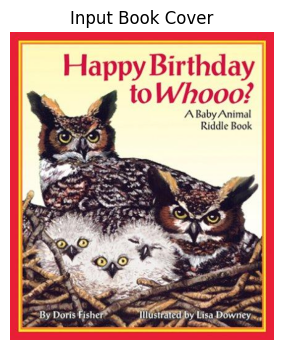

Predicted: baby books  (55.51% confidence)

Recommendations from category: 'baby books'
                  title          authors  rating                                                                                                                                                description
         Alligator Baby Robert N. Munsch     5.0       A little girl takes matters into her own hands after her brother is accidentally born in a zoo and her parents repeatedly bring home the wrong baby.
The reason for a flower      Ruth Heller     5.0 Brief text and lavish illustrations explain plant reproduction and the purpose of a flower and present some plants which don't seem to be flowers but are.
          Growing Frogs    Vivian French     5.0                                                                                          A mother and child watch as tadpoles develop and grow into frogs.

Testing with a 'cooking' cover:
IMAGE CHATBOT TEST (CNN)


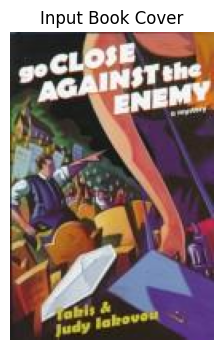

Predicted: japanese  (84.32% confidence)

Recommendations from category: 'japanese'
                     title            authors  rating                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

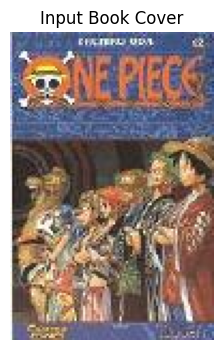

Predicted: japanese  (81.20% confidence)

Recommendations from category: 'japanese'
                     title            authors  rating                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

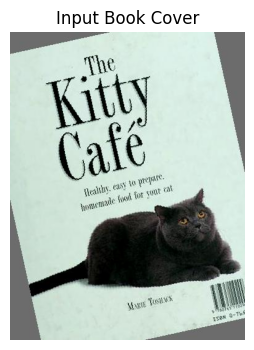

Predicted: kittens  (90.71% confidence)

Recommendations from category: 'kittens'
                               title                      authors  rating                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [59]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def test_image_chatbot(image_path, top_k=3):
    print("=" * 60)
    print("IMAGE CHATBOT TEST (CNN)")
    print("=" * 60)
    
    img = mpimg.imread(image_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Book Cover")
    plt.show()
    
    cat, recs = recommend_from_image(image_path, cnn_model=cnn3, top_k=top_k)  # ← cnn3 not h_cnn3_ft
    print(f"\nRecommendations from category: '{cat}'")
    print(recs.to_string(index=False))

import os, random
for cat in CATEGORIES:
    cat_folder = os.path.join(IMAGES_DIR, cat)
    images     = os.listdir(cat_folder)
    test_img   = os.path.join(cat_folder, random.choice(images))
    print(f"\nTesting with a '{cat}' cover:")
    test_image_chatbot(test_img, top_k=3)

# **1.Testing RNN models (claude limit) (done)
2. deleting transformer and adding another CNN model --
3. replace custom model with res net or any other CNN model --
4. image imbalance and data augmentation for data (pre processing) for CNN models-- 
5. fix any overfitting or underfitting if found **
6. handle notebook and make it look better and run 3and omar-- 
7. make GUI  --
8. edit all models rnn with tokenizer-- 
9. splitting csv  into test train val ---
10. rnn testing in gui is spamming 
11. add options to select specific model (cnn or rnn)  



In [ ]:
import os
from tensorflow.keras.models import load_model

models = {}

models_dir = "outputs"

for file in os.listdir(models_dir):
    if file.endswith(".keras"):
        model_path = os.path.join(models_dir, file)
        
        print(f"Loading {file}...")
        
        models[file] = load_model(model_path)

print("\nAll models loaded successfully!")
print("\nLoaded models:")

for name in models:
    print(name)

#  load all the models

In [15]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch
import pickle
import tensorflow as tf
import os 

# Load DistilBERT
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(os.path.join(OUTPUT_DIR, 'distilbert_final'))
bert_model     = DistilBertForSequenceClassification.from_pretrained(os.path.join(OUTPUT_DIR, 'distilbert_final'))
bert_model.eval()

# Load Keras models
cnn2 = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, 'cnn2_mobilenet.keras'))

# Load label encoder
le = pickle.load(open(os.path.join(OUTPUT_DIR, 'label_encoder.pkl'), 'rb'))

# Load cleaned dataframe
import pandas as pd
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'clean_books_dataset.csv'))

# Class names from image folder
import os
class_names = sorted(os.listdir(IMAGES_DIR))

print("All loaded successfully!")
print("class_names:", class_names)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

All loaded successfully!
class_names: ['baby books', 'cooking', 'japanese', 'kittens']


In [12]:
def build_mobilenet_cnn_fixed(num_classes=4):
    base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inp = layers.Input(shape=(224, 224, 3))
    x   = layers.Rescaling(scale=1./127.5, offset=-1)(inp)  # no Lambda
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = models.Model(inp, out, name='CNN_MobileNetV2')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

cnn2 = build_mobilenet_cnn_fixed()
cnn2.fit(train_img_ds, validation_data=val_img_ds, epochs=15, callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2),
])

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 52s 329ms/step - accuracy: 0.4305 - loss: 1.2906 - val_accuracy: 0.5622 - val_loss: 1.0640 - learning_rate: 1.0000e-04
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 45s 299ms/step - accuracy: 0.5708 - loss: 1.0114 - val_accuracy: 0.5893 - val_loss: 0.9861 - learning_rate: 1.0000e-04
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 45s 304ms/step - accuracy: 0.6179 - loss: 0.9331 - val_accuracy: 0.6088 - val_loss: 0.9396 - learning_rate: 1.0000e-04
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 44s 297ms/step - accuracy: 0.6241 - loss: 0.8875 - val_accuracy: 0.6257 - val_loss: 0.9138 - learning_rate: 1.0000e-04
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 45s 299ms/step - accuracy: 0.6505 - loss: 0.8568 - val_accuracy: 0.6308 - val_loss: 0.8963 - learning_rate: 1.0000e-04
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 44s 293ms/step - accuracy: 0.6558 - loss: 0.8296 - val_accuracy: 0.6384 - val_loss: 0.8830 - learning_rate: 1.0000e-04
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 43s 28

In [13]:
cnn2.save(os.path.join(OUTPUT_DIR, 'cnn2_mobilenet.keras'))
print("cnn2 overwritten with fixed version!")

cnn2 overwritten with fixed version!


In [2]:
test = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, 'cnn2_mobilenet.keras'))
print("OK:", test.name)

NameError: name 'os' is not defined

In [61]:
import os
class_names = sorted(os.listdir(IMAGES_DIR))
print("class_names:", class_names)

class_names: ['baby books', 'cooking', 'japanese', 'kittens']
